In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [3]:
# 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(308, 10)
(67, 10)
(67, 10)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [5]:
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(10,), name="hidden_1"),
    layers.Dense(32, activation="relu", name="hidden_2"),
    layers.Dense(16, activation="relu", name="hidden_3"),
    layers.Dense(1, activation="linear", name="output"),
])

model.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [7]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 29267.0918 - mae: 152.3987 - val_loss: 29625.1953 - val_mae: 154.2439
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29180.5723 - mae: 152.1122 - val_loss: 29523.0215 - val_mae: 153.9279
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29077.1719 - mae: 151.7755 - val_loss: 29403.1406 - val_mae: 153.5535
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28951.3574 - mae: 151.3632 - val_loss: 29256.6582 - val_mae: 153.0933
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28799.3125 - mae: 150.8524 - val_loss: 29076.2383 - val_mae: 152.5293
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28604.0527 - mae: 150.2255 - val_loss: 28854.3242 - val_mae: 151.8358
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28374.0840 - mae: 149.4580 - val_loss: 28577.3086 - val_mae: 150.9736
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28088.4453 - mae: 148.5017 - val_loss: 28232.3301 - va

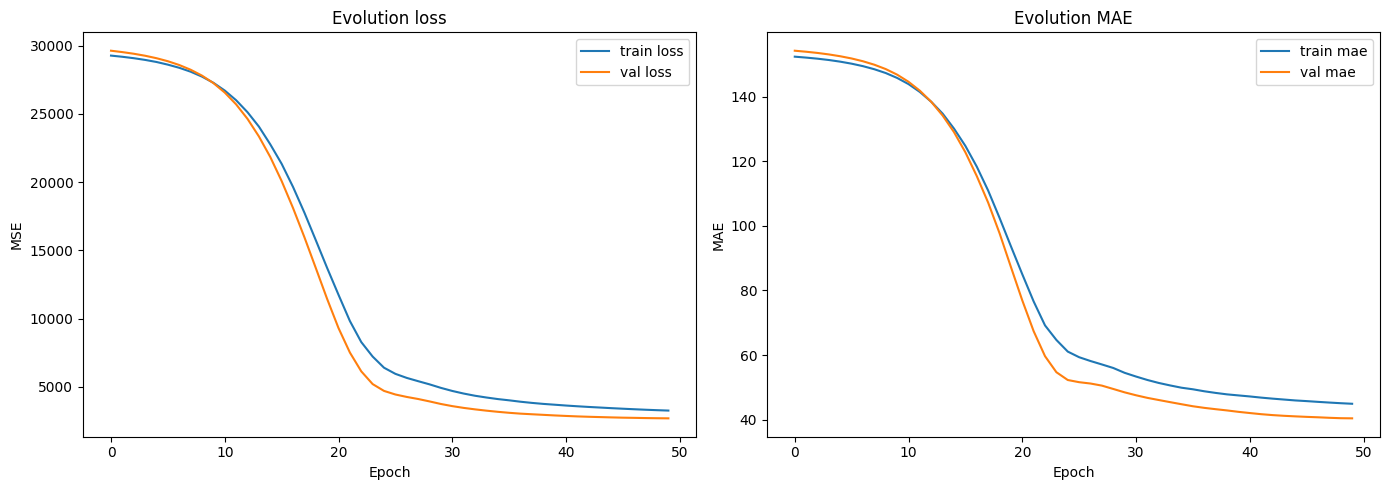

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.set_title("Evolution loss")
ax1.legend()

ax2.plot(history.history["mae"], label="train mae")
ax2.plot(history.history["val_mae"], label="val mae")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Evolution MAE")
ax2.legend()

plt.tight_layout()
plt.show()